<a href="https://www.kaggle.com/code/sonawanelalitsunil/global-jobs-gdp-unemployment-1991-2022?scriptVersionId=262105715" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-jobs-gdp-and-unemployment-data-19912022/Employment_Unemployment_GDP_data.csv


## 📊 Global Jobs, GDP & Unemployment (1991–2022)

## Description:
This dataset provides a comprehensive view of the global economic and labor market trends from 1991 to 2022. It includes key indicators such as Gross Domestic Product (GDP), employment levels, and unemployment rates across different countries and regions. The data enables analysis of how economic growth, financial crises, and global events have influenced job creation, workforce participation, and unemployment trends over three decades. Researchers, policymakers, and analysts can leverage this dataset to identify long-term economic patterns, compare regional disparities, and explore correlations between GDP growth and labor market conditions worldwide.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/global-jobs-gdp-and-unemployment-data-19912022/Employment_Unemployment_GDP_data.csv")

In [3]:
df.head()

,Country Name,Year,Employment Sector: Agriculture,Employment Sector: Industry,Employment Sector: Services,Unemployment Rate,GDP (in USD)
0,Albania,1991,53.299533,12.172764,34.527781,10.304,1.099559e+09
1,Algeria,1991,24.118566,25.067734,50.813700,20.600,4.571568e+10
2,Angola,1991,40.071857,8.163345,51.764822,16.855,1.060378e+10
3,Argentina,1991,13.669999,28.505903,57.824098,5.440,1.897200e+11
4,Armenia,1991,54.263252,15.790454,29.946294,1.783,2.069870e+09


In [4]:
df.tail()

,Country Name,Year,Employment Sector: Agriculture,Employment Sector: Industry,Employment Sector: Services,Unemployment Rate,GDP (in USD)
5746,Viet Nam,2022,33.609304,30.611964,35.778734,1.523,4.134452e+11
5747,Virgin Islands (U.S.),2022,1.293486,15.193240,83.513274,13.007,4.672000e+09
5748,West Bank and Gaza,2022,6.220994,32.609239,61.169768,24.420,1.916550e+10
5749,Zambia,2022,57.314602,10.346079,32.339318,5.995,2.916378e+10
5750,Zimbabwe,2022,52.610143,13.750807,33.639050,10.087,3.278966e+10


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5751 entries, 0 to 5750
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Country Name                    5751 non-null   object 
 1   Year                            5751 non-null   int64  
 2   Employment Sector: Agriculture  5751 non-null   float64
 3   Employment Sector: Industry     5751 non-null   float64
 4   Employment Sector: Services     5751 non-null   float64
 5   Unemployment Rate               5751 non-null   float64
 6   GDP (in USD)                    5751 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 314.6+ KB


In [6]:
df.describe()

,Year,Employment Sector: Agriculture,Employment Sector: Industry,Employment Sector: Services,Unemployment Rate,GDP (in USD)
count,5751.000000,5751.000000,5751.000000,5751.000000,5751.000000,5.751000e+03
mean,2006.568945,28.857051,19.773784,51.369166,8.155004,3.099333e+11
std,9.175548,24.026669,8.606954,18.892155,6.147428,1.375556e+12
min,1991.000000,0.107774,2.060372,5.314014,0.100000,7.228540e+07
25%,1999.000000,7.173214,13.889285,36.846735,3.659000,5.098458e+09
50%,2007.000000,22.172104,20.105516,52.657618,6.358000,1.972356e+10
75%,2014.000000,46.130703,25.345213,66.602313,10.996000,1.277237e+11
max,2022.000000,92.482036,59.579079,93.416932,38.800000,2.600689e+13


In [7]:
df.isnull().sum()

Country Name                      0
Year                              0
Employment Sector: Agriculture    0
Employment Sector: Industry       0
Employment Sector: Services       0
Unemployment Rate                 0
GDP (in USD)                      0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Country Name                       object
Year                                int64
Employment Sector: Agriculture    float64
Employment Sector: Industry       float64
Employment Sector: Services       float64
Unemployment Rate                 float64
GDP (in USD)                      float64
dtype: object

In [10]:
df.shape

(5751, 7)

In [11]:
df.columns

Index(['Country Name', 'Year', 'Employment Sector: Agriculture',
       'Employment Sector: Industry', 'Employment Sector: Services',
       'Unemployment Rate', 'GDP (in USD)'],
      dtype='object')

## Data visualizations

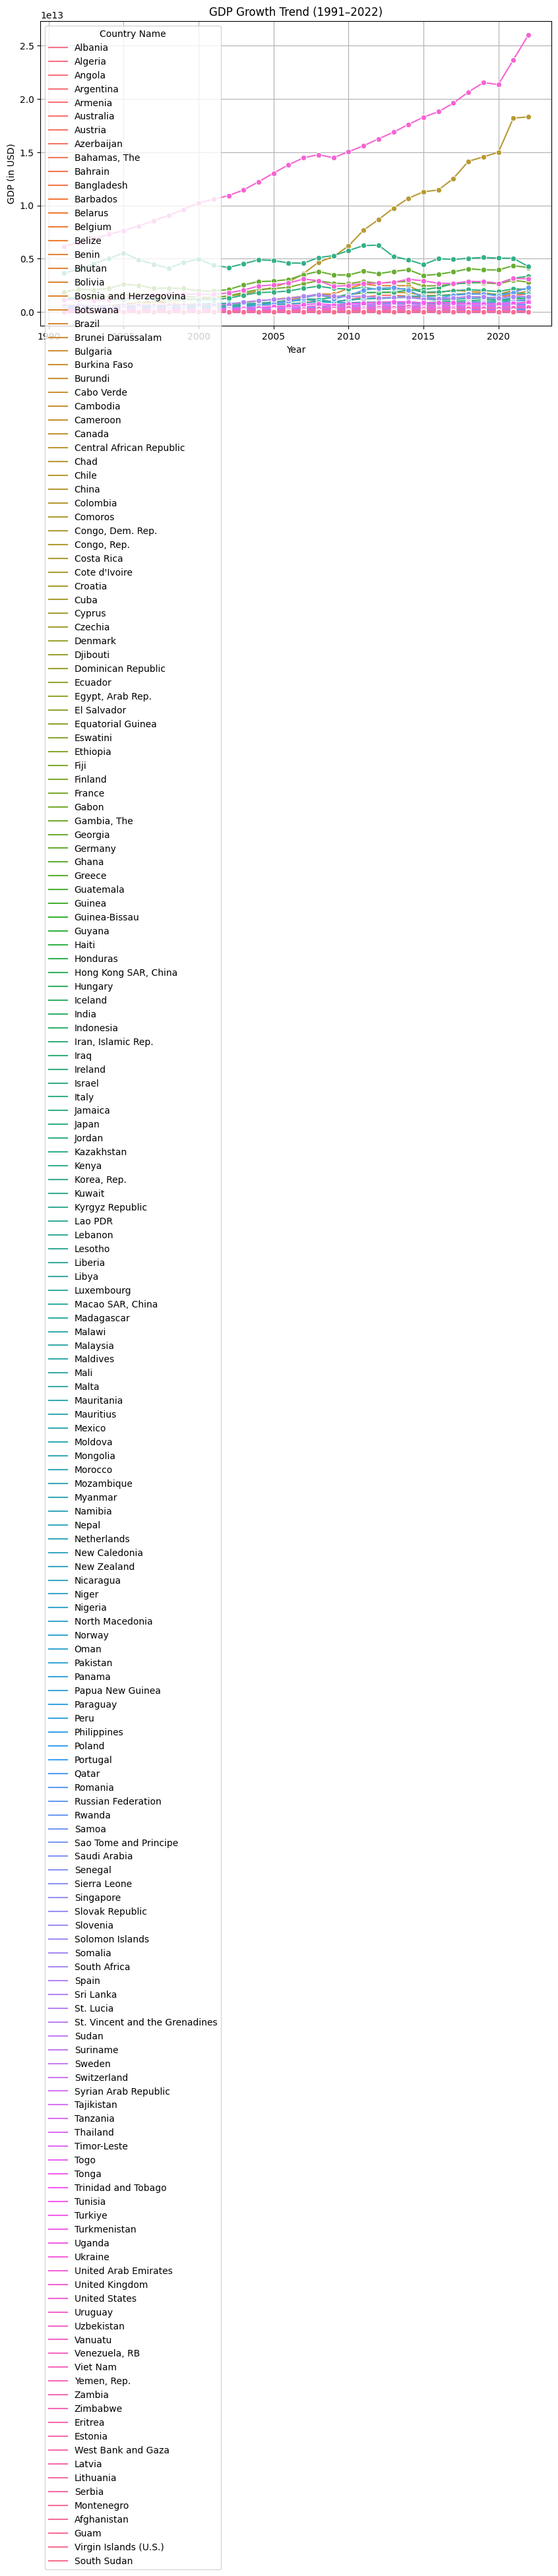

In [12]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Year', y='GDP (in USD)', hue='Country Name', marker="o")
plt.title("GDP Growth Trend (1991–2022)")
plt.ylabel("GDP (in USD)")
plt.grid(True)
plt.show()

In [13]:
import plotly.express as px

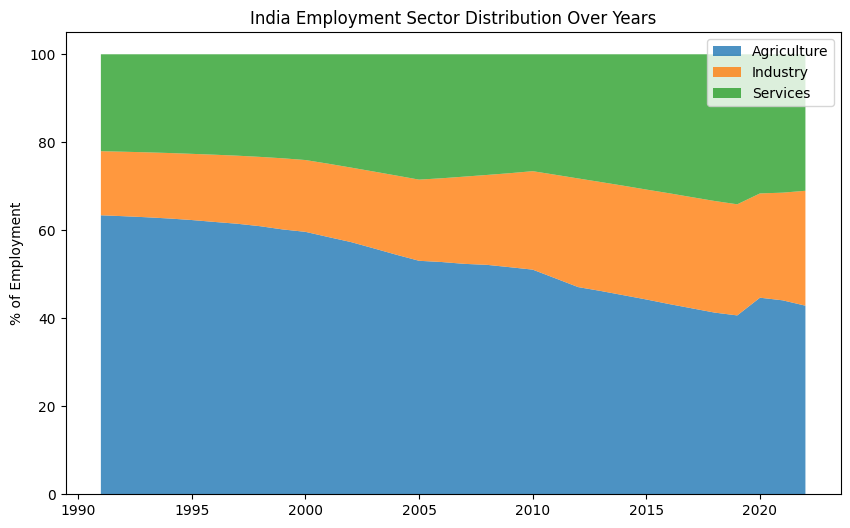

In [14]:
fig, ax = plt.subplots(figsize=(10,6))
df_india = df[df['Country Name']=='India']
ax.stackplot(df_india['Year'],
df_india['Employment Sector: Agriculture'],
df_india['Employment Sector: Industry'],
df_india['Employment Sector: Services'],
labels=['Agriculture','Industry','Services'], alpha=0.8)
ax.legend(loc='upper right')
plt.title("India Employment Sector Distribution Over Years")
plt.ylabel("% of Employment")
plt.show()

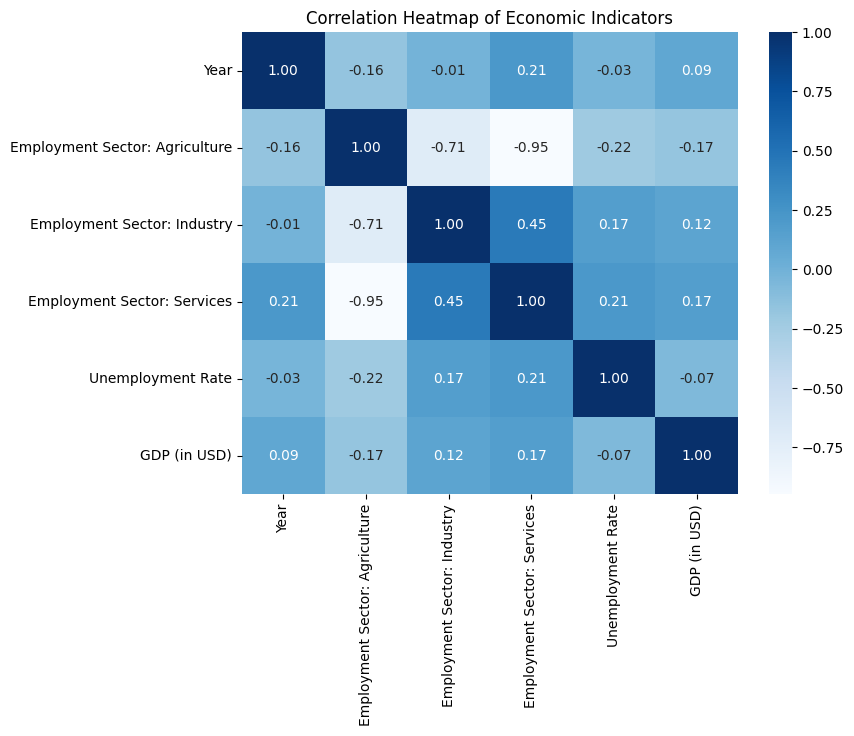

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop(columns=['Country Name']).corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap of Economic Indicators")
plt.show()

fig = px.sunburst(
df,
path=["Country Name","Year"],
values="GDP (in USD)",
color="Unemployment Rate",
color_continuous_scale="RdYlGn_r",
hover_data=["Employment Sector: Agriculture","Employment Sector: Industry","Employment Sector: Services"]
)
fig.update_layout(title="Sunburst: Country-Year GDP with Employment & Unemployment Insights")
fig.show()

fig = px.scatter(
df,
x="GDP (in USD)",
y="Unemployment Rate",
animation_frame="Year",
animation_group="Country Name",
size="GDP (in USD)",
color="Country Name",
hover_name="Country Name",
log_x=True,
size_max=60,
range_x=[1e9,2e13],
range_y=[0,12]
)
fig.update_layout(title="Animated GDP vs Unemployment (1991–2022)")
fig.show()

## Predictive modeling

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [17]:
features = ['Employment Sector: Agriculture','Employment Sector: Industry','Employment Sector: Services','Unemployment Rate']
target = 'GDP (in USD)'


prediction_df = df.dropna(subset=features + [target])
X = prediction_df[features]
y = prediction_df[target]


# Scale features (important for SVR/KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


# Define models
models = {
'Linear Regression': LinearRegression(),
'Decision Tree': DecisionTreeRegressor(random_state=42),
'Random Forest': RandomForestRegressor(random_state=42),
'Gradient Boosting': GradientBoostingRegressor(random_state=42),
'Support Vector Regressor': SVR(),
'KNN Regressor': KNeighborsRegressor()
}


results = []

In [18]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
accuracy = 100 - (rmse / y.mean() * 100)
results.append([name, rmse, accuracy])

In [19]:
results_df = pd.DataFrame(results, columns=["Model","RMSE","Accuracy %"])
print("\nModel Performance Summary:\n", results_df)


Model Performance Summary:
            Model          RMSE  Accuracy %
0  KNN Regressor  1.500069e+12 -383.997433


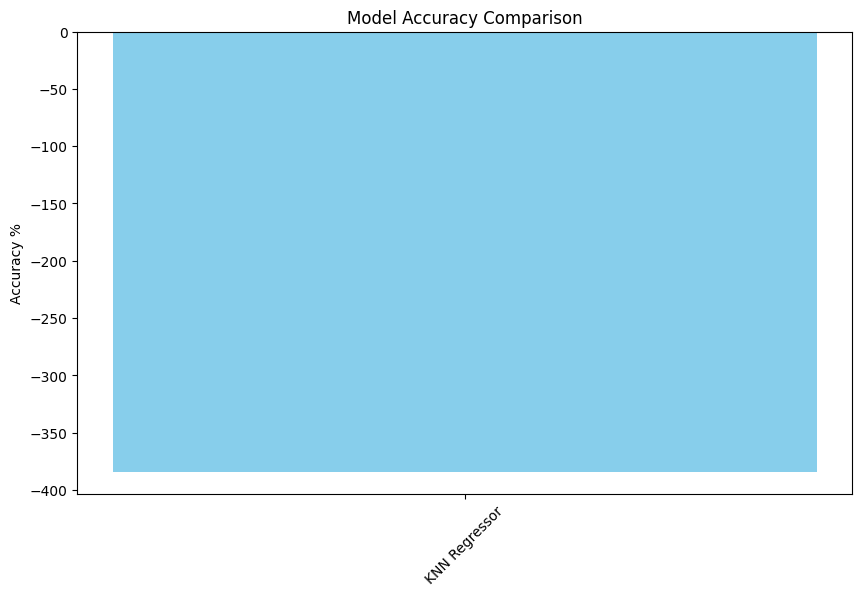

In [20]:
plt.figure(figsize=(10,6))
plt.bar(results_df['Model'], results_df["Accuracy %"], color="skyblue")
plt.ylabel("Accuracy %")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.show()

## Thank you..pls upvote!!!!